# Kaggle + Mendeley merge
2026 Joey Manani & Anchorfish Team

The final model in `classification_final.ipynb`) trains on both the Kaggle and two sets provided by Mendeley, `Phishing URLs.csv` and `URL dataset.csv`. 

This notebook checks that adding them was safe and predict whether they will enhance the model.

Same three tests as `eda_raw` (same-site, reality, research)

In [1]:
# Joey Manani 2026
# Same setup as eda_features.ipynb but Kaggle + Mendeley (features.csv)

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import to_rgba
from sklearn.metrics import roc_auc_score

import style

style.use()

############## SEE README ################
FINAL_TREE = Path("datasets/Final Tree")
DROPPED = Path("datasets/Extra Data")     # unzip datasets/Extra Data.zip here too containing Tranco set and urlset, two sources we tried and dropped (explained below)
##########################################
RAW               = FINAL_TREE / "1 Raw Data - Run These Through Cleaning Scripts"
CLEAN             = FINAL_TREE / "2. Cleaned Data - Already Processed With Cleaning Scripts"
FEATURES          = FINAL_TREE / "4. Final Data - Run Through Feature Extractor Script" / "features.csv"
FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

SCHEME = r"^[a-zA-Z][a-zA-Z0-9+.-]*://"  # http://, https://
LABELS = ["Legitimate", "Phishing"]
SOURCES = ["Kaggle", "Phishing URLs", "URL dataset"]  # the last two are the Mendeley files

df = pd.read_csv(FEATURES, keep_default_na=False)

# which source each URL came from. A URL that is in more than one source counts as the first one (Kaggle first)
kaggle_urls   = set(pd.read_csv(CLEAN / "kaggle_clean.csv", keep_default_na=False).url)
phishing_urls = set(pd.read_csv(CLEAN / "phish_clean.csv", keep_default_na=False).url)
df["source"] = np.where(df.url.isin(kaggle_urls), "Kaggle", np.where(df.url.isin(phishing_urls), "Phishing URLs", "URL dataset")) # add a source column

TEXT_COLUMNS = ["url", "type", "tld", "root_domain", "source"]  # not model inputs
FEATURE_COLUMNS = [c for c in df.columns if c not in TEXT_COLUMNS]

# what the classifier will see
legit_and_phishing = df[df.type.isin(LABELS)].copy()
is_phishing = legit_and_phishing.type.eq("Phishing")

print(f"{len(df)} rows, {len(FEATURE_COLUMNS)} features, {len(legit_and_phishing)} of them legit or phishing")

786062 rows, 54 features, 667194 of them legit or phishing


## 1. What the sources contributes
The merge script keeps one URL if it appears identical in both sources (deduplicates), and removes URLs that two sources label differently (conflicts)

In [2]:
pd.crosstab(df.source, df.type, margins=True)

type,Defacement,Legitimate,Malware,Phishing,All
source,,,,,
Kaggle,95284,427816,23584,86033,632717
Phishing URLs,0,0,0,52032,52032
URL dataset,0,5636,0,95677,101313
All,95284,433452,23584,233742,786062


In [3]:
steps = pd.DataFrame({
    "raw file": [len(pd.read_csv(RAW / f)) for f in ["malicious_phish.csv", "Phishing URLs.csv", "URL dataset.csv"]],
    "after its own cleaning": [len(pd.read_csv(CLEAN / f)) for f in ["kaggle_clean.csv", "phish_clean.csv", "urlds_clean.csv"]],
    "adds to the merge": df.source.value_counts().reindex(SOURCES).values,
}, index=SOURCES)
steps

,raw file,after its own cleaning,adds to the merge
Kaggle,651191,632722,632717
Phishing URLs,54807,54799,52032
URL dataset,450176,449826,101313


Kaggle file has 651191 raw rows, and 632722 after cleaning. It contributes 632717 lines to the merged dataset (deduped & conflicts removed)

Phishing URLs has 54807 raw rows, and 54799 after cleaning. It contributes 52032 lines to the merged dataset (deduped & conflicts removed)

URL dataset has 450176 rows, and 449826 after cleaning. It contributes 101313 lines to the merged dataset (deduped & conflicts removed) - lots clearly overlapped with the Kaggle set.

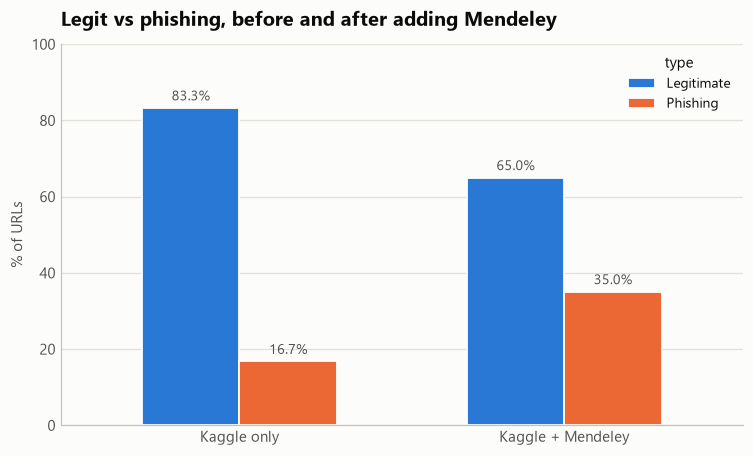

,Kaggle only,Kaggle + Mendeley
type,,
Legitimate,83.3,65.0
Phishing,16.7,35.0


In [4]:
from_kaggle = legit_and_phishing.source.eq("Kaggle")

balance = pd.DataFrame({
    "Kaggle only": legit_and_phishing.type[from_kaggle].value_counts(normalize=True),
    "Kaggle + Mendeley": legit_and_phishing.type.value_counts(normalize=True),
}).loc[LABELS] * 100

ax = balance.T.plot.bar(rot=0, width=0.6, color=style.colours(LABELS), ylabel="% of URLs", ylim=(0, 100), title="Legit vs phishing, before and after adding Mendeley")
ax.grid(False, axis="x")

for bars in ax.containers:
    ax.bar_label(bars, fmt="%.1f%%", padding=3, color=style.INK_SOFT, fontsize=9)
style.save(ax.figure, FIGURES / "merged_class_balance.png")
plt.show()
balance.round(1)

- Kaggle is still most of the data: 632,717 of the 786,062 rows
- Phishing URLs from Mendeley is 54,807 raw rows. 8 were unreadable and 2,767 were already in Kaggle, so it contributes 52,032
- URL dataset from Mendeley is 450,176 raw rows but only adds 101,313: 5,636 legit and 95,677 phishing. After cleaning, duplicates are dropped
- Mendeley adds almost only phishing. Legit vs phishing goes from 83.3 / 16.7 to 65.0 / 35.0
- Always guessing "legit" now only gets 65% accuracy, and precision is naturally a bit higher because phishing is less rare. Thresholds picked on the Kaggle-only data (0.25 in `classification.ipynb`) can't be reused, which is why `classification_final.ipynb` must pick it differently
- `classification.ipynb` can be treated as an early experiment on just the Kaggle set in this case.

## 2. Did cleaning make the sources look the same?
Each raw file was created in a different way therefore they might store URLs differently.

Four formatting flags, as % of each source and type, similar to `eda_raw`:

- **has scheme** and **starts www.** say how the list was written down, not what the site is (same-site test)
- **has a path** anything after the host
- **ends with /** another storage quirk that can affect the model

Pale bars show raw files, solid bars are after each source's process script. Tranco and urlset only have pale bars, because they were dropped - further down

In [5]:
def formatting(urls):
    urls = urls.astype(str)
    bare = urls.str.replace(SCHEME, "", regex=True)
    return pd.DataFrame({
        "has scheme": urls.str.match(SCHEME),
        "starts www.": bare.str.match(r"(?i)www\d*\."),
        "has a path": bare.str.split("/", n=1).str[1].fillna("") != "",  # anything after the first /
        "ends with /": urls.str.endswith("/"),
    })


kaggle_raw        = pd.read_csv(RAW / "malicious_phish.csv")
phishing_urls_raw = pd.read_csv(RAW / "Phishing URLs.csv")
url_dataset_raw   = pd.read_csv(RAW / "URL dataset.csv")
 
tranco_raw        = pd.read_csv(DROPPED / "tranco_processed.csv")
urlset_raw        = pd.read_csv(DROPPED / "urlset.csv", usecols=["domain", "label"], encoding="latin-1", engine="python", on_bad_lines="skip")  # no processing script to remove bad chars, but we want to use it in this eda so we need to skip bad lines

# one table of every raw source, type, url
raw = pd.concat([
    pd.DataFrame({"source": "Kaggle",        "type": kaggle_raw.type.map(style.KAGGLE_NAMES),                                                "url": kaggle_raw.url}),
    pd.DataFrame({"source": "Phishing URLs", "type": "Phishing",                                                                             "url": phishing_urls_raw.url}),
    pd.DataFrame({"source": "URL dataset",   "type": url_dataset_raw.type.str.capitalize(),                                                  "url": url_dataset_raw.url}),
    pd.DataFrame({"source": "Tranco",        "type": "Legitimate",                                                                           "url": tranco_raw.url}),
    pd.DataFrame({"source": "urlset",        "type": pd.to_numeric(urlset_raw.label, errors="coerce").map({0: "Legitimate", 1: "Phishing"}), "url": urlset_raw.domain}), # this set had no processing script, so just briefly map the labels
], ignore_index=True)
raw = raw[raw.type.isin(LABELS)] # just keep the desired labels - legitimate and phishing

# load the cleaned data and append a source column with the source name same as above
cleaned = pd.concat([
    pd.read_csv(CLEAN / "kaggle_clean.csv", keep_default_na=False).assign(source="Kaggle"),
    pd.read_csv(CLEAN / "phish_clean.csv",  keep_default_na=False).assign(source="Phishing URLs"),
    pd.read_csv(CLEAN / "urlds_clean.csv",  keep_default_na=False).assign(source="URL dataset"),
], ignore_index=True)

cleaned = cleaned[cleaned.type.isin(LABELS)]  # again, just desired labels for this one: legitimate and phishing

raw_pct   = formatting(raw.url)    .groupby([raw.source, raw.type]).mean() * 100
clean_pct = formatting(cleaned.url).groupby([cleaned.source, cleaned.type]).mean().reindex(raw_pct.index) * 100

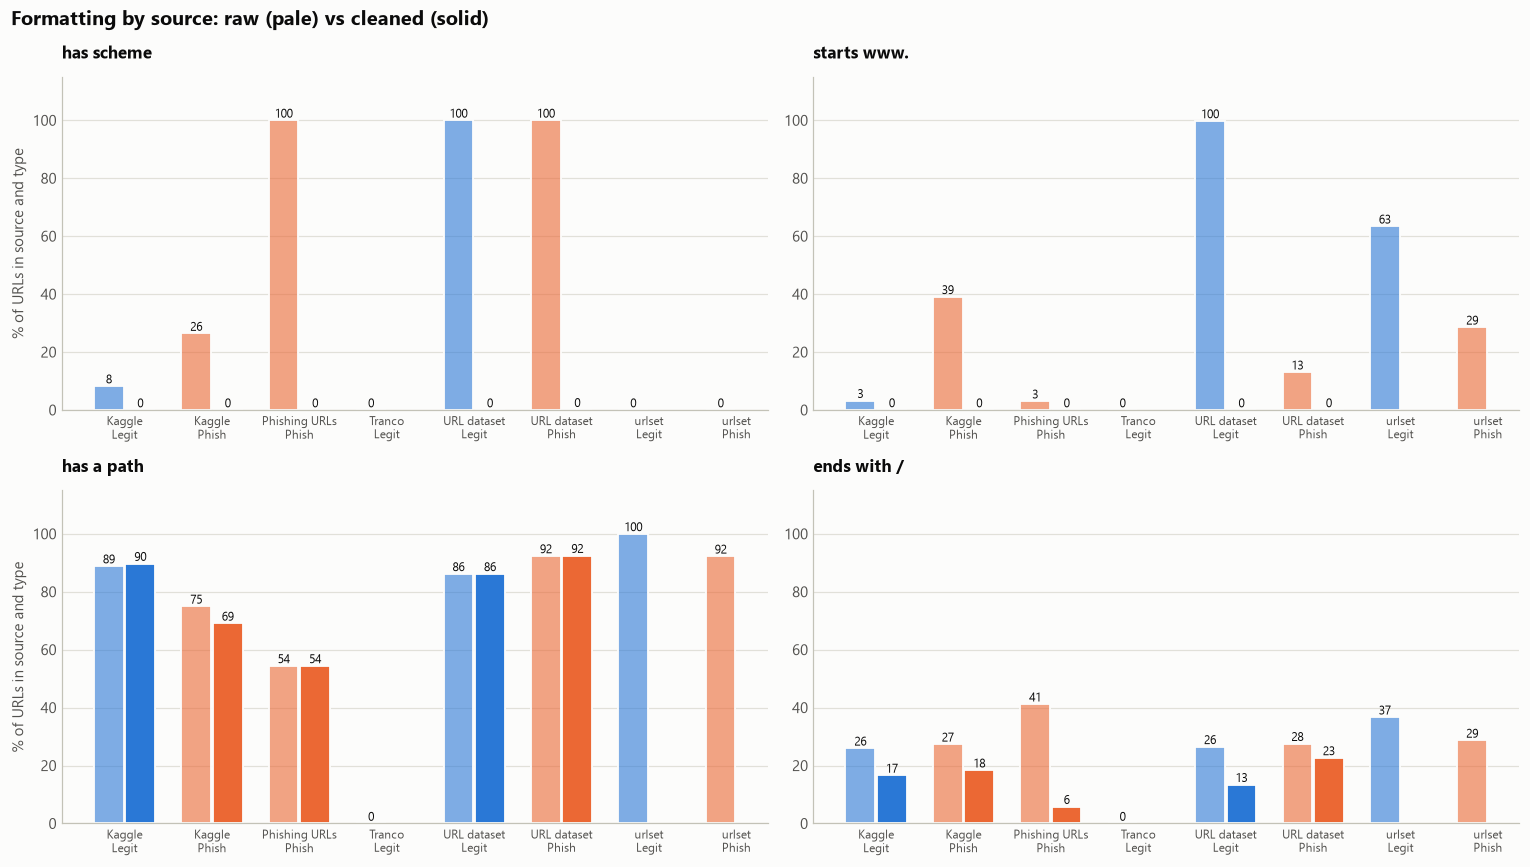

raw                                     \
                         has scheme starts www. has a path ends with /   
source        type                                                       
Kaggle        Legitimate        8.3         3.2       88.9        26.0   
              Phishing         26.4        39.1       75.0        27.4   
Phishing URLs Phishing        100.0         3.0       54.4        41.2   
Tranco        Legitimate        0.0         0.0        0.0         0.0   
URL dataset   Legitimate      100.0        99.8       86.2        26.5   
              Phishing        100.0        13.1       92.4        27.6   
urlset        Legitimate        0.0        63.4      100.0        36.7   
              Phishing          0.0        28.6       92.3        28.7   

                            cleaned                                     
                         has scheme starts www. has a path ends with /  
source        type                                                      
Kaggle        Legitimate        0.0         0.0       89.7        16.6  
              Phishing          0.0         0.0       69.1        18.4  
Phishing URLs Phishing          0.0         0.0       54.4         5.8  
Tranco        Legitimate        NaN         NaN        NaN         NaN  
URL dataset   Legitimate        0.0         0.0       86.2        13.4  
              Phishing          0.1         0.0       92.5        22.7  
urlset        Legitimate        NaN         NaN        NaN         NaN  
              Phishing          NaN         NaN        NaN         NaN

In [6]:
groups = raw_pct.index
pos_offset_x = np.arange(len(groups))
colours = [style.TYPE_COLOURS[t] for _, t in groups]
pale = [to_rgba(c, 0.6) for c in colours]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, flag in zip(axes.flat, raw_pct.columns):
    raw_bars   = ax.bar(pos_offset_x - 0.18, raw_pct[flag],   0.34, color=pale)
    clean_bars = ax.bar(pos_offset_x + 0.18, clean_pct[flag], 0.34, color=colours)
    ax.bar_label(raw_bars, fmt="%.0f", fontsize=8)
    ax.bar_label(clean_bars, labels=[f"{v:.0f}" if pd.notna(v) else "" for v in clean_pct[flag]], fontsize=8)
    ax.set_xticks(pos_offset_x, [f"{s}\n{t[:5]}" for s, t in groups], fontsize=8)
    ax.set_title(flag, fontsize=11)
    ax.set_ylim(0, 115)

for ax in axes[:, 0]:  # left side only
    ax.set_ylabel("% of URLs in source and type")

fig.suptitle("Formatting by source: raw (pale) vs cleaned (solid)", x=0.01, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
style.save(fig, FIGURES / "merged_formatting_by_source.png")
plt.show()

pd.concat({"raw": raw_pct, "cleaned": clean_pct}, axis=1).round(1)

- Both of the Mendeley files have a scheme on all rows, while Kaggle on 8% of legit and 26% of phishing. URL dataset's legit URLs start with www 99.8% of the time, its phishing only 13%. The model would learn that if a URL starts with `https://www.` it would mean legit. Shortcutted, and fails the same-site test
- After processing/cleaning, scheme and www. are basically 0% everywhere - URL dataset phishing has 0.1% left with a scheme, insignificant 
- "Has a path" is not changed by cleaning since it's real content, but it still differs: Kaggle legit 90%, Kaggle phishing 69%, Phishing URLs 54%, URL dataset phishing 92%. This actually describes the sites, not how they were stored because phishing can exist on subdomains that try to mimic legitimate sites like paypal.com.secure.BADWEBSITE.xyz. It passes the reality test.
- "Ends with /" drops for every source after cleaning, most for Phishing URLs (41% to 6%), because many of its URLs were a bare host with a `/` on the end. Failed same-site test so it had to be cleaned.

### 2b. Why Tranco and urlset were dropped
Both were tried during data collection and left out of the final merge. We found some major issues with both of these.

In [7]:
# urlset: how many of its URLs are already in the raw Kaggle file
kaggle_first = kaggle_raw.reset_index().drop_duplicates("url").set_index("url")
 
urlset_rows = raw[raw.source == "urlset"]
in_kaggle   = urlset_rows.url.isin(kaggle_first.index)
matched     = kaggle_first.loc[urlset_rows.url[in_kaggle]]

print(f"urlset URLs: {len(urlset_rows):,}, also in the raw Kaggle file: {in_kaggle.mean():.1%}")
print(f"  of those, in Kaggle's swapped blocks (row 555,186 onwards): {(matched['index'] >= 555186).mean():.1%}")
print(f"  of those, same label as the raw Kaggle file: {(urlset_rows.type[in_kaggle].values == matched.type.map(style.KAGGLE_NAMES).values).mean():.1%}")

urlset URLs: 95,912, also in the raw Kaggle file: 100.0%
  of those, in Kaggle's swapped blocks (row 555,186 onwards): 100.0%
  of those, same label as the raw Kaggle file: 0.0%


This confirms the suspicion from `eda_raw`. It seems the Kaggle dataset's author pasted in the ENTIRE urlset (Aalto University, 2014) and accidentally had the labels the wrong way around!

100% of the urlset URLs are therefore in the Kaggle dataset, but with the wrong labels and starts after row 555186 as we have seen.

Marchal, S. (2014) *PhishStorm – phishing / legitimate URL dataset.* Aalto University. Available at: [Aalto University Research Portal](https://research.aalto.fi/en/datasets/phishstorm-phishing-legitimate-url-dataset/) (Accessed: 7 September 2026).

In [8]:
# Tranco: one million top-site domains, all legitimate
legit_has_path    = formatting(legit_and_phishing.url[np.logical_not(is_phishing)])["has a path"]
phishing_has_path = formatting(legit_and_phishing.url[is_phishing])["has a path"]

# These two are meant to be somewhat equal since phishing and legitimates can both have shallow or deep paths
print(f"Phishing URLs with a path: {phishing_has_path.mean():.1%}")
print(f"Legit URLs with a path, now: {legit_has_path.mean():.1%}")
print(f"Legit URLs with a path, if Tranco domains were added: {legit_has_path.sum() / (len(legit_has_path) + len(tranco_raw)):.1%}")

Phishing URLs with a path: 75.8%
Legit URLs with a path, now: 88.7%
Legit URLs with a path, if Tranco domains were added: 26.8%


- Tranco provides 1M domains that are all legit, with 0% scheme and 0% paths as shown before. It is a list of homepages/root domains.
- Legit URLs with a path would drop from 88.7% to 26.8%, while phishing stays at 75.8% (Tranco adds no phishing URLs). It dilutes the legitimate set.
- "Has a path" would become a shortcut for phishing, which fails the reality test. It has to be dropped

## 3. URL length and Paths (cleaned data)

We need to ensure that one source's URLs are not significantly different to another's. This causes the model to stop understanding that length is an indicator of phishing.

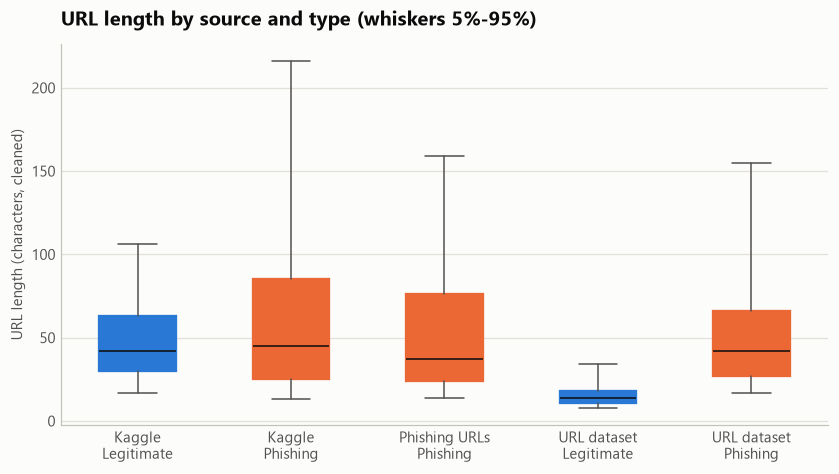

URLs  median length  % with a path
source        type                                            
Kaggle        Legitimate  427816           42.0           89.7
              Phishing     86033           45.0           69.1
Phishing URLs Phishing     52032           37.0           56.3
URL dataset   Legitimate    5636           14.0           10.1
              Phishing     95677           42.0           92.5

In [9]:
groups = legit_and_phishing.groupby(["source", "type"]).url
keys = [key for key, _ in groups]

fig, ax = plt.subplots(figsize=(9, 4.5))
boxes = ax.boxplot(
    [urls.str.len() for _, urls in groups],
    tick_labels=[f"{source}\n{type}" for source, type in keys],
    whis=(5, 95),
    showfliers=False,
    widths=0.5,
    patch_artist=True,
    whiskerprops={"color": style.INK_SOFT},
    capprops={"color": style.INK_SOFT},
)

for box, (_, type) in zip(boxes["boxes"], keys):
    box.set(facecolor=style.TYPE_COLOURS[type], edgecolor=style.TYPE_COLOURS[type], linewidth=1.5)

ax.set_ylabel("URL length (characters, cleaned)")
ax.set_title("URL length by source and type (whiskers 5%-95%)")
style.save(fig, FIGURES / "merged_length_by_source.png")
plt.show()

pd.DataFrame({
    "URLs": groups.size(),
    "median length": groups.apply(lambda urls: urls.str.len().median()),
    "% with a path": groups.apply(lambda urls: formatting(urls)["has a path"].mean() * 100),
}).round(1)

- Kaggle legit (median 42), Kaggle phishing (45) and URL dataset phishing (42) are close
- Phishing URLs is shorter (37) and only 56% have a path
- URL dataset's 5636 legit URLs have a median of 14 characters and only 10% have a path. They are also homepages, like Tranco. 
- URL dataset makes up 1.3% of the legitimate URLs, and theres still a large number of phishing that doesn't have a path in so it doesn't turn into a shortcut. No further actions required. Removing it would be not be unreasonable either.

## 4. Does any feature become a shortcut?
Same single-feature AUC as `eda_features` section 4 (0.5 = random, 1.0 = separates the two types on its own, anything above 0.8 is suspicious). Kaggle-only vs merged, side by side.

Above 0.8 (suspicious): []


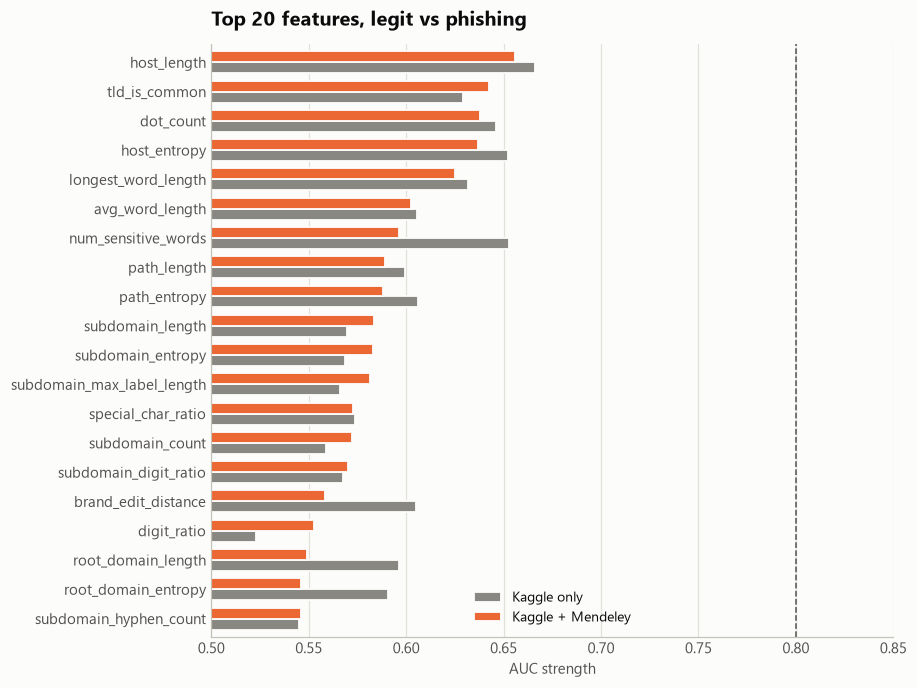

,Kaggle only,Kaggle + Mendeley
host_length,0.666,0.656
tld_is_common,0.629,0.643
dot_count,0.646,0.638
host_entropy,0.652,0.637
longest_word_length,0.632,0.625
avg_word_length,0.605,0.603
num_sensitive_words,0.653,0.596
path_length,0.599,0.589
path_entropy,0.606,0.588
subdomain_length,0.570,0.584


In [10]:
def strength(values, target):
    auc = pd.Series({feat: roc_auc_score(target, values[feat]) for feat in values.columns})
    return np.maximum(auc, 1 - auc)  # both directions are equally informative

usable = [feat for feat in FEATURE_COLUMNS if legit_and_phishing[feat].nunique() > 1] # only features with more than 1 unique value
values = legit_and_phishing[usable].astype(float)

auc = pd.DataFrame({
    "Kaggle only": strength(values[from_kaggle], is_phishing[from_kaggle]),
    "Kaggle + Mendeley": strength(values, is_phishing),
}).sort_values("Kaggle + Mendeley", ascending=False)

print("Above 0.8 (suspicious):", auc.index[auc["Kaggle + Mendeley"] > 0.8].tolist())


top20 = auc.head(20).iloc[::-1]
ax = top20.plot.barh(figsize=(8, 7), width=0.75, color=[style.MUTED, style.TYPE_COLOURS["Phishing"]], xlim=(0.5, 0.85), title="Top 20 features, legit vs phishing")
ax.axvline(0.8, color=style.INK_SOFT, linewidth=1, linestyle="--")
ax.set_xlabel("AUC strength")
ax.grid(False, axis="y")
style.save(ax.figure, FIGURES / "merged_aucs.png")
plt.show()

auc.head(20).round(3)

- Still, nothing goes above 0.8 with the strongest feature is still host_length (0.656). No shortcut features.
- Most features don't move by much
- num_sensitive_words drops 0.653 to 0.596, brand_edit_distance drops 0.605 to 0.558, root_domain_length and root_domain_entropy also drop the most. Mendeley's phishing uses fewer sensitive words and fewer brand names in the domain. This explains why `classification_final`s section 3, model B (Kaggle + Mendeley) got worse on Kaggle rows, and part of why adding Naive Bayes on the raw characters helped so much there. The number of sensitive words is no longer as big.
- subdomain-scoped features and digit_ratio rise because modern phishing sites tend to use subdomains of free hosting, such as sjfdgnjnfsgdjkn.workers.dev.

## 5. Where is each source's phishing hosted?
Top root domains among the phishing URLs, as % of that source's phishing.

In [11]:
phish = legit_and_phishing[is_phishing]

for source, urls in phish.groupby("source"):
    print(source, f"({len(urls):,} phishing URLs)")
    print((urls.root_domain.value_counts(normalize=True).head(8) * 100).round(2), "\n")

Kaggle (86,033 phishing URLs)
root_domain
googlegroups     1.72
000webhostapp    1.38
pastehtml        1.12
blogspot         0.84
google           0.82
sharepoint       0.42
                 0.37
bit              0.35
Name: proportion, dtype: float64 

Phishing URLs (52,032 phishing URLs)
root_domain
google             7.36
cf-ipfs            6.78
weeblysite         6.40
cloudflare-ipfs    6.16
r2                 4.55
aragon             4.19
web                4.06
firebaseapp        4.01
Name: proportion, dtype: float64 

URL dataset (95,677 phishing URLs)
root_domain
                 4.12
google           1.28
000webhostapp    0.95
mhcable          0.40
adnxs            0.27
wixsite          0.26
twitter          0.23
blogspot         0.23
Name: proportion, dtype: float64 



- Kaggle: the top host is only 1.7% googlegroups, then 000webhostapp, pastehtml and blogspot. These are older free hosting services
- Mendeley Phishing URLs: Google (Docs/Sites) 7.36%, IPFS links 13% total, weeblysite 6.4%, Cloudflare R2 4.55%, Firebase 4.01%. These are free, quick to set up and sit under trusted domains. IPFS is decentralised too meaning it's harder to track and blacklist - is_ipfs would be a good feature to have
- Mendeley URL dataset: similar to Kaggle, spread out, with 4.12% IP hosts (the empty root_domain` row) followed by google, 000webhost, mhcable...

## 6. Findings and decisions

| Section | What it showed | Decision |
|---------|----------------|----------|
| 1. What each source adds | Mendeley adds 147,709 phishing but only 5,636 legit. Most of `URL dataset` was already in Kaggle. Phishing goes from 16.7% to 35% | Thresholds will need to be re-evaluated on the merged data |
| 2. Formatting | Raw: scheme and www. depend on the source. After cleaning they're unified to be 0% everywhere | Cleaning worked, the sources look the same |
| 2b. Dropped sources | urlset is Kaggle's swapped block with the right labels. Tranco is 1M homepages with no paths | Drop both. Tranco would make "has a path" mean phishing |
| 3. Length | All sources have similar lengths, except Mendeley's 5,636 legit homepages (median 14) | Keep them, too few to be a shortcut, but can be dropped |
| 4. Feature AUC | Nothing above 0.8. Sensitive words features get weaker, subdomain features get stronger | No shortcut. Newer phishing uses fewer sensitive words |
| 5. Hosting | Mendeley's phishing URLs are common on free hosts like Google services, IPFS, Weebly, R2, Firebase | Train/Test set split is fine. `is_ipfs` could be a future feature |

No further actions required. 

## References

- Matplotlib (n.d.) *Bar chart with labels*. Available at: https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html.
- Matplotlib (n.d.) *Grouped bar chart with labels*. Available at: https://matplotlib.org/stable/gallery/lines_bars_and_markers/barchart.html.
- Matplotlib (n.d.) *Horizontal bar chart*. Available at: https://matplotlib.org/stable/gallery/lines_bars_and_markers/barh.html.
- Matplotlib (n.d.) *Box plots with custom fill colors*. Available at: https://matplotlib.org/stable/gallery/statistics/boxplot_color.html.
- pandas (n.d.) *pandas.crosstab*. Available at: https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html.
- scikit-learn (n.d.) *roc_auc_score*. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html.